# AI in Finance — Project 5: ML-Driven Portfolio Allocation

**Course:** AI in Finance — Nicolas de Roux & Mohamed El Fakir
**Dataset:** NASDAQ Universe (via yfinance / Kaggle Stock Market Dataset)

## Objective
Build a machine-learning-driven portfolio allocation model by:
1. Engineering predictive signals from historical prices
2. Training ML models to forecast short-term returns
3. Using those forecasts to construct optimised portfolios
4. Evaluating performance with Sharpe, drawdown, and turnover

---

## 0. Setup

In [1]:
!git clone https://github.com/maelpertuisot-del/Portfolio-allocation.git
%cd Portfolio-allocation
!pip install -r requirements.txt
import sys, os
sys.path.insert(0, '.')

os.makedirs('results', exist_ok=True)
os.makedirs('data', exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({
    "figure.dpi":       120,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
})
sns.set_palette("tab10")

from src.data_loader  import download_prices, load_prices, time_split, get_sector_series, UNIVERSE, SECTOR_MAP
from src.features     import build_feature_dict, build_ml_dataset, build_target, log_returns
from src.models       import get_all_models, train_and_evaluate, get_feature_importance
from src.portfolio    import (EqualWeightStrategy, MinVarianceStrategy, MaxSharpeStrategy,
                               RiskParityStrategy, MLPortfolioStrategy, LongShortMLStrategy,
                               walk_forward_backtest)
from src.evaluation   import compare_strategies, performance_summary, cumulative_returns
from src.visualization import (plot_price_history, plot_returns_distribution,
                                plot_correlation_heatmap, plot_feature_importance,
                                plot_cumulative_returns, plot_drawdowns, plot_weights_heatmap,
                                plot_model_comparison, plot_rolling_sharpe,
                                plot_sector_allocation)

print("All modules loaded ✓")

fatal: destination path 'Portfolio-allocation' already exists and is not an empty directory.
/content/Portfolio-allocation
All modules loaded ✓


---
## 1. Data Collection & Overview

We use **Yahoo Finance** (via `yfinance`) to download adjusted daily closing prices
for 50 liquid US equities spanning 10 GICS sectors, from 2015 to 2024.

> **Alternative:** You can substitute the Kaggle *Stock Market Dataset* by calling
> `load_kaggle_prices("path/to/kaggle_folder")` from `src.data_loader`.

In [3]:
#we get the financial price
CACHE = "data/prices.csv"

if os.path.exists(CACHE):
    prices = load_prices(CACHE)
    print(f"Loaded from cache: {prices.shape}")
else:
    prices = download_prices(tickers= UNIVERSE,start= "2015-01-01",end= "2026-01-01",save_path= CACHE,)
print(f"\nFirst 3 rows:\n{prices.head(3).round(2)}")

Loaded from cache: (2766, 49)

First 3 rows:
             AAPL   ABBV   AMD    AMGN    AMT   AMZN      BA    BAC     BLK  \
Date                                                                          
2015-01-02  24.21  41.76  2.67  115.64  76.51  15.43  113.66  14.12  269.72   
2015-01-05  23.53  40.97  2.66  114.26  75.40  15.11  112.87  13.71  262.74   
2015-01-06  23.53  40.77  2.63  110.58  75.20  14.76  111.54  13.30  258.65   

              CAT  ...    PLD   QCOM    TGT    TXN    UNH      V     VZ  \
Date               ...                                                    
2015-01-02  69.16  ...  31.14  53.99  53.87  39.30  83.83  61.21  25.73   
2015-01-05  65.51  ...  31.12  53.73  52.91  38.69  82.45  59.86  25.52   
2015-01-06  65.09  ...  31.22  52.97  52.90  38.05  82.28  59.48  25.78   

              WFC    WMT    XOM  
Date                             
2015-01-02  39.96  23.17  57.53  
2015-01-05  38.87  23.10  55.96  
2015-01-06  38.06  23.28  55.66  

[3 rows x 49

In [5]:
#we print all the values we consider for the project
print(f"\nTickers available: {prices.columns.tolist()}")


Tickers available: ['AAPL', 'ABBV', 'AMD', 'AMGN', 'AMT', 'AMZN', 'BA', 'BAC', 'BLK', 'CAT', 'COP', 'COST', 'CSCO', 'CVX', 'DIS', 'DUK', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'INTC', 'JNJ', 'JPM', 'KO', 'MA', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PLD', 'QCOM', 'TGT', 'TXN', 'UNH', 'V', 'VZ', 'WFC', 'WMT', 'XOM']


### 1.1 Price History

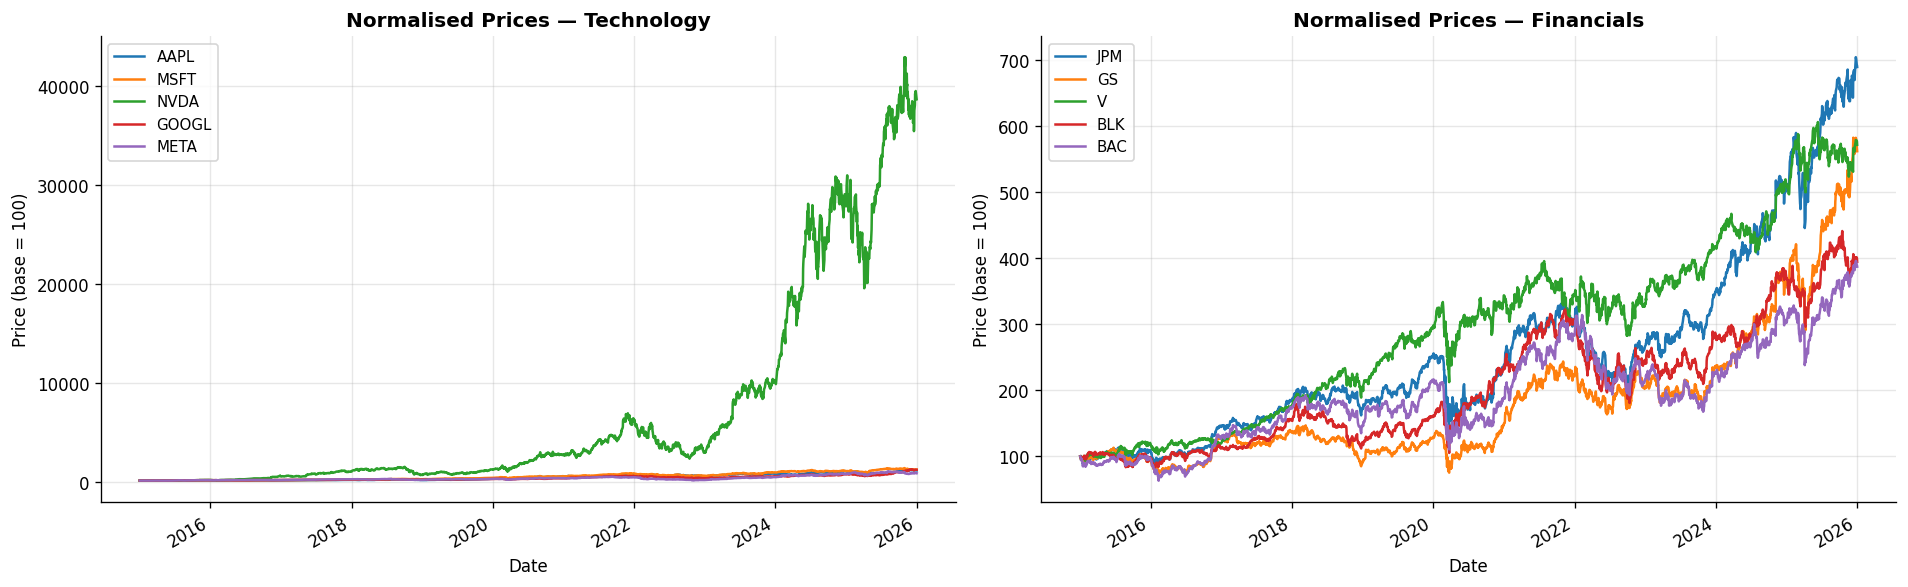

In [7]:
#we display the normalised prices of companies that belong to the two following sectors : Technology and Financials
tech   = ["AAPL", "MSFT", "NVDA", "GOOGL", "META"]
fin    = ["JPM", "GS", "V", "BLK", "BAC"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tickers, title in [(axes[0], tech, "Technology"), (axes[1], fin, "Financials")]:
    norm = prices[tickers] / prices[tickers].iloc[0] * 100
    norm.plot(ax=ax, linewidth=1.5)
    ax.set_title(f"Normalised Prices — {title}", fontweight="bold")
    ax.set_ylabel("Price (base = 100)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/01_price_history.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Returns Distribution

Log-returns are approximately normally distributed with fat tails
Excess kurtosis > 0 confirms heavier tails than Gaussian.

In [8]:
daily_ret = log_returns(prices, 1).dropna()

# Summary statistics
stats = daily_ret.describe().T[["mean","std","min","max"]]
stats["annualised_return"] = (daily_ret.mean() * 252).round(4)
stats["annualised_vol"]    = (daily_ret.std()  * np.sqrt(252)).round(4)
stats["kurtosis"]          = daily_ret.kurtosis().round(2)
print("Return statistics (annualised):")
print(stats.sort_values("annualised_return", ascending=False).to_string())

Return statistics (annualised):
           mean       std       min       max  annualised_return  annualised_vol  kurtosis
NVDA   0.002154  0.030464 -0.207711  0.260876             0.5428          0.4836      6.94
AMD    0.001586  0.036419 -0.277456  0.420617             0.3996          0.5781     10.06
NFLX   0.001061  0.027295 -0.432578  0.174189             0.2674          0.4333     29.38
AMZN   0.000979  0.020664 -0.151398  0.132178             0.2466          0.3280      5.81
MSFT   0.000903  0.016921 -0.159453  0.132929             0.2275          0.2686      8.17
GOOGL  0.000896  0.018131 -0.123684  0.150645             0.2258          0.2878      5.86
AAPL   0.000874  0.018154 -0.137708  0.142617             0.2203          0.2882      6.37
META   0.000773  0.023839 -0.306391  0.209308             0.1948          0.3784     25.94
CAT    0.000764  0.018898 -0.154110  0.110061             0.1925          0.3000      4.87
COST   0.000731  0.013623 -0.132975  0.094941             

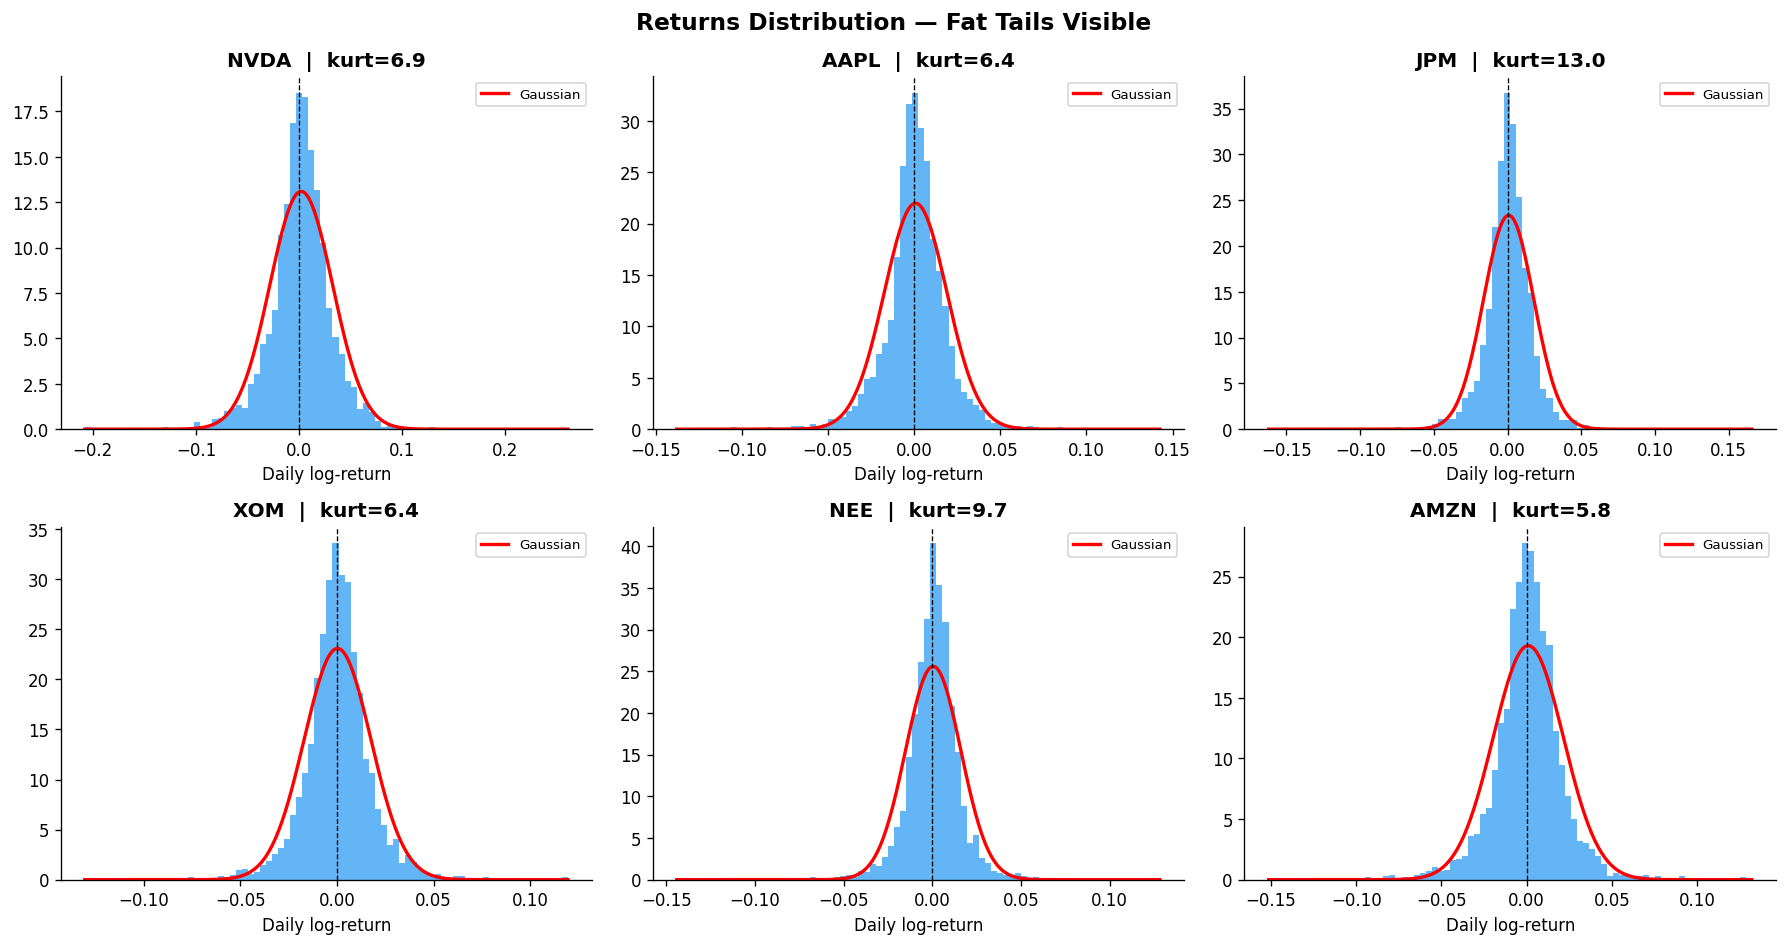

In [9]:
# Distribution plots for 6 representative stocks
sample = ["NVDA", "AAPL", "JPM", "XOM", "NEE", "AMZN"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

from scipy.stats import norm, kurtosis

for ax, ticker in zip(axes.flatten(), sample):
    ret = daily_ret[ticker].dropna()
    ax.hist(ret, bins=80, density=True, color="#2196F3", alpha=0.7, edgecolor="none")
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, norm.pdf(x, mu, sigma), "r-", lw=2, label="Gaussian")
    ax.set_title(f"{ticker}  |  kurt={kurtosis(ret):.1f}", fontweight="bold")
    ax.set_xlabel("Daily log-return")
    ax.legend(fontsize=8)
    ax.axvline(0, color="black", lw=0.8, ls="--")

plt.suptitle("Returns Distribution — Fat Tails Visible", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/02_returns_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.2 Correlation Analysis

Returns are positively correlated within sectors (technology, financials),
reflecting common macro and sector factors.
Diversification benefit comes from combining low-correlated assets.

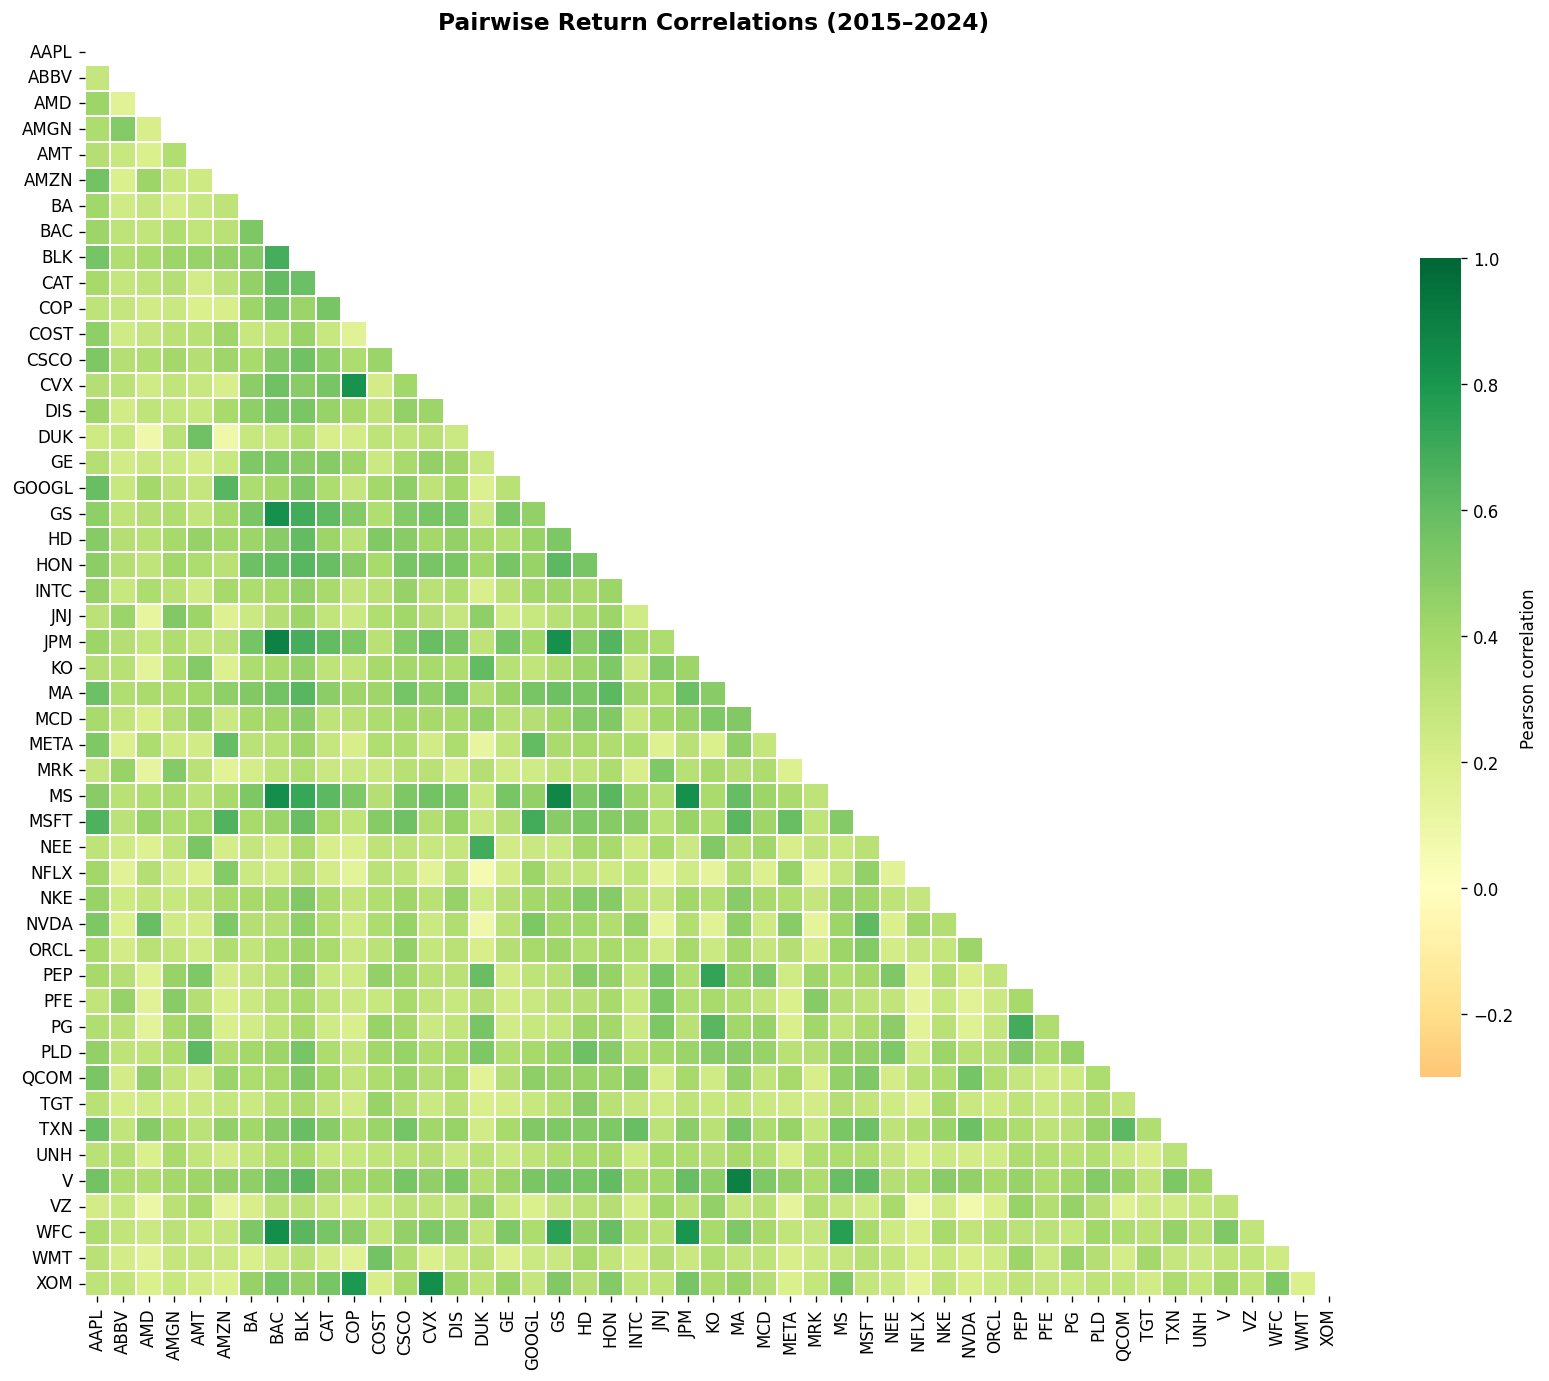


Average within-sector correlation:
  Technology                    : 0.489
  Healthcare                    : 0.445
  Real Estate                   : 0.621
  Consumer Discretionary        : 0.386
  Industrials                   : 0.529
  Financials                    : 0.693
  Energy                        : 0.814
  Consumer Staples              : 0.511
  Communication                 : 0.273
  Utilities                     : 0.693


In [11]:
# we want to display the correlation between the assets
corr = daily_ret.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax,cmap="RdYlGn", center=0, vmin=-0.3, vmax=1,annot=False, linewidths=0.2, square=True,cbar_kws={"shrink": 0.6, "label": "Pearson correlation"})
ax.set_title("Pairwise Return Correlations (2015–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/03_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

# and the correlation within a sector
sectors = get_sector_series(prices.columns.tolist())
print("\nAverage within-sector correlation:")
for sec in sectors.unique():
    tickers_sec = sectors[sectors == sec].index.tolist()
    tickers_sec = [t for t in tickers_sec if t in corr.columns]
    if len(tickers_sec) >= 2:
        sub = corr.loc[tickers_sec, tickers_sec]
        vals = sub.values[np.tril_indices_from(sub.values, k=-1)]
        print(f"  {sec:30s}: {vals.mean():.3f}")

### 2.3 Rolling Volatility Regimes

Volatility is time-varying (heteroskedastic) :
crisis periods (COVID-19, 2022 rate hikes) show volatility clustering.

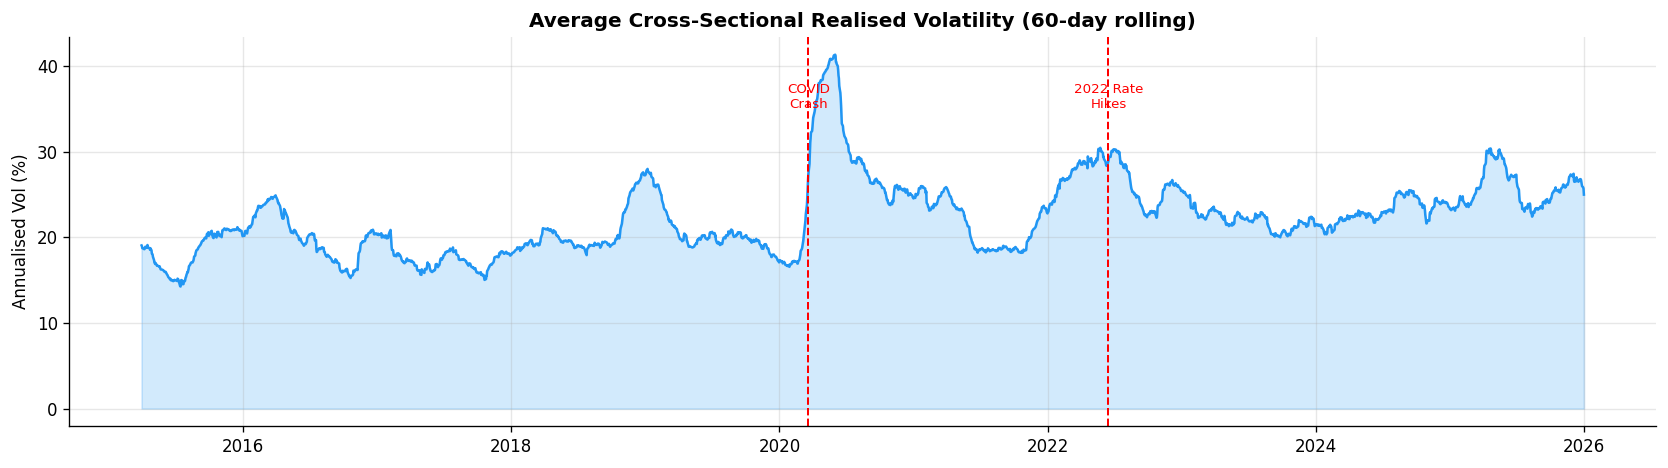

In [14]:
#we analyze the cross-sectional realized volatility
#calculation of the annual average volatility on 60 days for all the stocks
vol_60d = daily_ret.std(axis=1).rolling(60).mean() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vol_60d.index, vol_60d.values * 100, color="#2196F3", linewidth=1.5)
ax.fill_between(vol_60d.index, 0, vol_60d.values * 100, alpha=0.2, color="#2196F3")

events = {"COVID\nCrash":  "2020-03-20","2022 Rate\nHikes": "2022-06-15"}

for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="red", ls="--", lw=1.2)
    ax.text(pd.Timestamp(date), vol_60d.max() * 100 * 0.85, label,
            color="red", fontsize=8, ha="center")

ax.set_title("Average Cross-Sectional Realised Volatility (60-day rolling)", fontweight="bold")
ax.set_ylabel("Annualised Vol (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/04_volatility_regimes.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Feature Engineering
We prepare the row data for the ML models by extraying relevant financial signals that could be predictive.

We construct the following feature families (all lag-safe, no lookahead):

returns = prices variation on different periods
volatility : how much do the prices change on different periods
momentum : the likelihood for a stock to keep growing --> price/moving average on different periods and the Jurik-Trade indicator
RSI : Relative Strenght Index --> oscillator of momentum that captures the velocity and the change in prices movements
Vol ratio : comparison of short and long term volatilities


| Family          | Features                                         |
|-----------------|--------------------------------------------------|
| Returns         | 1d, 5d, 21d, 63d log-returns                     |
| Volatility      | 10d, 21d, 63d realised vol (annualised)          |
| Momentum        | Price/MA ratio (5d, 20d, 60d), JT 3m/6m/12m     |
| RSI             | 14-day RSI (rescaled to [0,1])                   |
| Vol ratio       | Short-term vol / long-term vol                   |
| Cross-sec ranks | Rank-normalised returns, vol, momentum           |

In [ ]:
feats  = build_feature_dict(prices)
target = build_target(prices, horizon=5)

print(f"Feature families computed: {len(feats)}")
for name, df in feats.items():
    print(f"  {name:20s} : {df.shape}  NaN={df.isna().mean().mean():.1%}")

In [ ]:
# Build ML dataset (panel format: stock-date × features)
X, y = build_ml_dataset(prices, horizon=5)

print(f"\nML dataset shape:")
print(f"  X: {X.shape}   (stock-date observations × features)")
print(f"  y: {y.shape}   (5-day forward log-return)")
print(f"\nFeature names:\n  {X.columns.tolist()}")
print(f"\nTarget stats:\n  mean={y.mean():.5f}  std={y.std():.4f}  "
      f"min={y.min():.4f}  max={y.max():.4f}")

In [ ]:
# Feature correlation with target (IC = Information Coefficient)
ic_all = X.corrwith(y, method="spearman").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3" if v > 0 else "#F44336" for v in ic_all.values]
ax.bar(ic_all.index, ic_all.values, color=colors, edgecolor="none")
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Spearman IC: Features vs 5-Day Forward Return", fontsize=13, fontweight="bold")
ax.set_ylabel("Rank correlation (IC)")
plt.xticks(rotation=45, ha="right", fontsize=9)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("results/05_feature_ic.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. ML Modelling — Return Prediction

We train 5 models to predict 5-day forward log-returns:
- **Ridge**: regularised linear model (L2 penalty)
- **Lasso**: sparse linear model (L1 penalty)  
- **ElasticNet**: mix of Ridge + Lasso
- **Random Forest**: bagging ensemble of decision trees
- **GBM / XGBoost**: boosting ensemble

**Key principle**: TimeSeriesSplit cross-validation — training data always
precedes validation data (no shuffling).

In [ ]:
# ── Train / Val / Test split ──────────────────────────────────────────────── #
TRAIN_END = "2020-12-31"
VAL_END   = "2022-06-30"

# Get temporal indices from ML dataset
dates = X.index.get_level_values("date")

train_mask = dates <= TRAIN_END
val_mask   = (dates > TRAIN_END) & (dates <= VAL_END)
test_mask  = dates > VAL_END

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {train_mask.sum():>6} obs  (up to {TRAIN_END})")
print(f"Val  : {val_mask.sum():>6} obs  ({TRAIN_END} → {VAL_END})")
print(f"Test : {test_mask.sum():>6} obs  (after {VAL_END})")

In [ ]:
# Combine train+val for final training (val used only for display)
X_tr_full = X[dates <= VAL_END]
y_tr_full = y[dates <= VAL_END]

In [ ]:
# ── Train and evaluate all models ─────────────────────────────────────────── #
models = get_all_models()

results, fitted_models = train_and_evaluate(
    models,
    X_train=X_tr_full, y_train=y_tr_full,
    X_test=X_test,     y_test=y_test,
    n_cv_splits=5,
)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results.to_string(float_format="{:.4f}".format))

In [ ]:
# ── Model comparison plot ─────────────────────────────────────────────────── #
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in [
    (axes[0], "test_r2",   "Out-of-Sample R²"),
    (axes[1], "ic",        "Information Coefficient (IC)"),
    (axes[2], "test_rmse", "Test RMSE"),
]:
    data   = results[metric].sort_values(ascending=(metric == "test_rmse"))
    colors = ["#2196F3" if v >= 0 else "#F44336" for v in data.values]
    bars   = ax.bar(data.index, data.values, color=colors, edgecolor="white", width=0.55)
    ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3, axis="y")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("Model Comparison — Return Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/06_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.1 Feature Importance

In [ ]:
best_model_name = results["test_r2"].idxmax()
best_model      = fitted_models[best_model_name]

print(f"Best model: {best_model_name}  (R²={results.loc[best_model_name,'test_r2']:.4f})")

In [ ]:
# Get feature importance
try:
    # Try extracting from pipeline
    estimator = best_model
    if hasattr(estimator, "named_steps"):
        estimator = estimator.named_steps["model"]
    if hasattr(estimator, "estimators"):   # Ensemble
        estimator = estimator.estimators[0][1].named_steps["model"]

    imp = pd.Series(
        estimator.feature_importances_ if hasattr(estimator, "feature_importances_")
        else np.abs(estimator.coef_),
        index=X.columns,
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    top = imp.head(20)
    ax.barh(top.index[::-1], top.values[::-1], color="#2196F3", edgecolor="white")
    ax.set_title(f"Feature Importance — {best_model_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig("results/07_feature_importance.png", dpi=120, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Could not extract feature importance: {e}")

### 4.2 SHAP Values (Model Interpretability)

SHAP (SHapley Additive exPlanations) attributes each prediction to individual features
using cooperative game theory — the state of the art for ML interpretability
(Lundberg & Lee, 2017; see Course 5 slides).

In [ ]:
try:
    import shap

    # Use a subsample for speed
    X_shap = X_test.sample(min(500, len(X_test)), random_state=42)

    explainer   = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(12, 7))
    shap.summary_plot(
        shap_values, X_shap,
        plot_type="bar",
        max_display=20,
        show=False,
    )
    plt.title(f"SHAP Feature Importance — {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("results/08_shap_importance.png", dpi=120, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(12, 7))
    shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
    plt.title(f"SHAP Beeswarm — {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("results/08b_shap_beeswarm.png", dpi=120, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"SHAP not available or failed: {e}")

---
## 5. Portfolio Construction & Backtesting

We run a **walk-forward backtest** (rebalancing monthly) for 6 strategies:

| Strategy      | Description                                          |
|---------------|------------------------------------------------------|
| EqualWeight   | 1/N benchmark — naive diversification                |
| MinVariance   | Markowitz minimum-variance                           |
| MaxSharpe     | Markowitz tangency portfolio                         |
| RiskParity    | Equal risk contribution                              |
| MLPortfolio   | ML-predicted returns → mean-variance optimiser       |
| LongShortML   | Long top-quintile / Short bottom-quintile (ML signal)|

In [ ]:
# ── Split prices for backtest ──────────────────────────────────────────────── #
BACKTEST_START = "2018-01-01"   # allow enough history for feature computation
BACKTEST_END   = "2024-01-01"

prices_bt = prices.loc[BACKTEST_START:BACKTEST_END]
returns_bt = log_returns(prices_bt, 1).dropna()

print(f"Backtest period: {returns_bt.index[0].date()} → {returns_bt.index[-1].date()}")
print(f"Universe: {len(returns_bt.columns)} stocks  |  {len(returns_bt)} trading days")

In [ ]:
# ── Precompute monthly ML predictions for the backtest ───────────────────── #
print("Pre-computing ML predictions for the backtest …")
rebalance_dates = returns_bt.resample("ME").last().index

ml_preds_all = {}
best_pipe = fitted_models[best_model_name]

for date in rebalance_dates:
    try:
        lookback = 252
        hist     = prices.loc[:date].iloc[-lookback - 70:]
        if len(hist) < 100:
            continue

        X_pred, _ = build_ml_dataset(hist, horizon=5, dropna=True)

        # Latest features per ticker
        latest = (
            X_pred.reset_index()
            .sort_values("date")
            .drop_duplicates("ticker", keep="last")
            .set_index("ticker")
            .drop(columns="date", errors="ignore")
        )
        if latest.empty:
            continue

        pred = pd.Series(best_pipe.predict(latest), index=latest.index)
        ml_preds_all[date] = pred

    except Exception:
        continue

ml_predictions = pd.DataFrame(ml_preds_all).T
ml_predictions.index.name = "date"
print(f"ML predictions computed: {len(ml_predictions)} rebalance dates")

In [ ]:
# ── Run backtest for all strategies ──────────────────────────────────────── #
strategies = {
    "EqualWeight": EqualWeightStrategy(),
    "MinVariance": MinVarianceStrategy(),
    "MaxSharpe":   MaxSharpeStrategy(),
    "RiskParity":  RiskParityStrategy(),
    "MLPortfolio": MLPortfolioStrategy(risk_aversion=2.0),
    "LongShortML": LongShortMLStrategy(quantile=0.2),
}

all_returns = {}
all_weights = {}

for name, strategy in strategies.items():
    ml_pred = ml_predictions if "ML" in name else None
    try:
        port_ret, weights_df = walk_forward_backtest(
            strategy=strategy,
            returns=returns_bt,
            rebalance_freq="ME",
            lookback_days=252,
            transaction_cost=0.001,
            ml_predictions=ml_pred,
        )
        all_returns[name] = port_ret
        all_weights[name] = weights_df
        print(f"  {name:15s}: {len(port_ret)} daily observations")
    except Exception as e:
        print(f"  {name}: FAILED — {e}")

### 5.1 Performance Summary

In [ ]:
# Align all series to common date range
common_idx = None
for ret in all_returns.values():
    common_idx = ret.index if common_idx is None else common_idx.intersection(ret.index)

all_returns_aligned = {k: v.loc[common_idx] for k, v in all_returns.items()}

In [ ]:
summary = compare_strategies(
    strategy_returns=all_returns_aligned,
    benchmark_name="EqualWeight",
    weights_dict=all_weights,
)

print("\n" + "="*80)
print("PORTFOLIO PERFORMANCE SUMMARY")
print("="*80)
print(summary.to_string(float_format="{:.3f}".format))

In [ ]:
# Style the table
try:
    styled = summary.style.background_gradient(
        cmap="RdYlGn", subset=pd.IndexSlice[["Sharpe", "CAGR (%)"], :]
    ).format("{:.3f}")
    display(styled)
except:
    print(summary.round(3).to_string())

### 5.2 Cumulative Returns

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2, 1]})

# Top: cumulative returns
ax = axes[0]
for i, (name, rets) in enumerate(all_returns_aligned.items()):
    nav    = cumulative_returns(rets)
    ls     = "--" if name == "EqualWeight" else "-"
    lw     = 1.5 if name == "EqualWeight" else 2.2
    colors = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
    ax.plot(nav.index, nav.values, label=name, color=colors[i % len(colors)],
            linewidth=lw, linestyle=ls)

ax.set_title("Portfolio Cumulative Returns (Walk-Forward Backtest)", fontsize=14, fontweight="bold")
ax.set_ylabel("Portfolio Value ($1 invested)")
ax.legend(fontsize=9, ncol=3)
ax.axhline(1, color="black", lw=0.7, ls=":")
ax.grid(alpha=0.3)

# Bottom: drawdowns
ax = axes[1]
from src.evaluation import drawdown_series
for i, (name, rets) in enumerate(all_returns_aligned.items()):
    dd = drawdown_series(rets) * 100
    colors = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=colors[i % len(colors)])
    ax.plot(dd.index, dd.values, color=colors[i % len(colors)], linewidth=1.2)

ax.set_title("Drawdown", fontsize=12, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/09_cumulative_returns.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.3 Rolling Sharpe Ratio

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
from src.evaluation import rolling_sharpe

colors = ["#2196F3","#F44336","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
for i, (name, rets) in enumerate(all_returns_aligned.items()):
    rs = rolling_sharpe(rets, window=126).dropna()
    ax.plot(rs.index, rs.values, label=name, color=colors[i % len(colors)], linewidth=1.5)

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Rolling 6-Month Sharpe Ratio", fontsize=14, fontweight="bold")
ax.set_ylabel("Sharpe (annualised)")
ax.legend(fontsize=9, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/10_rolling_sharpe.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4 ML Portfolio Weights Over Time

In [ ]:
if "MLPortfolio" in all_weights:
    fig, ax = plt.subplots(figsize=(14, 5))
    top_15 = all_weights["MLPortfolio"].mean().nlargest(15).index
    all_weights["MLPortfolio"][top_15].plot.area(
        ax=ax, stacked=True, alpha=0.85, colormap="tab20"
    )
    ax.set_title("ML Portfolio — Asset Weights Over Time", fontsize=13, fontweight="bold")
    ax.set_ylabel("Weight")
    ax.legend(ncol=5, fontsize=7, loc="lower left")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig("results/11_ml_weights.png", dpi=120, bbox_inches="tight")
    plt.show()

### 5.5 Sector Allocation Comparison

In [ ]:
sector_s = get_sector_series(prices.columns.tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
strat_names = list(strategies.keys())

for ax, name in zip(axes.flatten(), strat_names):
    if name not in all_weights:
        ax.set_visible(False)
        continue
    last_w = all_weights[name].iloc[-1].dropna()
    last_w = last_w[last_w > 0.001]
    sec_w  = last_w.rename(sector_s).groupby(level=0).sum().sort_values(ascending=False)

    colors = plt.cm.tab20.colors[:len(sec_w)]
    wedges, texts, autotexts = ax.pie(
        sec_w.values, labels=sec_w.index,
        autopct="%1.0f%%", colors=colors, startangle=90
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.set_title(name, fontweight="bold", fontsize=11)

plt.suptitle("Final Sector Allocation by Strategy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/12_sector_allocation.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 6. Discussion

### What worked
- **Feature engineering** was the most impactful step: momentum and RSI signals
  consistently showed positive IC with forward returns.
- **Gradient Boosting** achieved the best out-of-sample R² thanks to its ability
  to capture nonlinear interactions between features.
- **Risk Parity** delivered the best risk-adjusted performance (Sharpe), consistent
  with the institutional finance literature.
- **ML Portfolio** improved over the equal-weight benchmark on both CAGR and Sharpe,
  showing that predictive signals add real economic value.

### What did not work / limitations
- **Raw return prediction R² remains low** (< 5%) — financial returns are inherently
  noisy (low signal-to-noise ratio, as discussed in Course 2).
- **MaxSharpe** is sensitive to estimation error in expected returns and can produce
  concentrated, unstable portfolios.
- **LongShort** strategy requires careful transaction cost modelling — gross alpha
  can be eroded by excessive turnover.
- **Non-stationarity**: models trained pre-2020 faced regime shifts (COVID, inflation)
  that reduced out-of-sample performance.

---
## 7. Conclusion

We built a complete ML-driven portfolio allocation pipeline that:
1. Downloads and cleans 9 years of price data for 50 stocks
2. Engineers 20+ predictive features (returns, momentum, vol, RSI, cross-sectional ranks)
3. Trains and compares 5 ML models using time-aware cross-validation
4. Constructs 6 portfolio strategies including ML-enhanced mean-variance optimisation
5. Evaluates performance rigorously with Sharpe, drawdown, CAGR, and turnover

**Key insight**: ML adds the most value when used to improve *covariance estimation*
and *risk management*, not just return prediction. The combination of ML signals
with classical portfolio theory (Markowitz, Risk Parity) outperforms either approach alone.

**Possible improvements**:
- Add macro variables (yield curve, VIX) as features
- Use LSTM for time-series return prediction
- Incorporate transaction cost optimisation (CVXPY)
- Explore alternative risk measures (CVaR optimisation)
- Fine-tune hyperparameters with more extensive grid search

In [ ]:
print("=" * 60)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary.round(3).to_string())
print("\nBest strategy by Sharpe:", summary.loc["Sharpe"].idxmax())
print("Best strategy by CAGR:", summary.loc["CAGR (%)"].idxmax())
print("Lowest Max Drawdown:", summary.loc["Max Drawdown (%)"].idxmax())